# Causal-JEPA — an annotated reproduction

**Paper.** *Causal-JEPA: Learning World Models through Object-Level Latent Masking* —
Heejeong Nam, Quentin Le Lidec, Lucas Maes, Yann LeCun, Randall Balestriero.
ICML 2026. arXiv:2602.11389

**Code.** `github.com/Maverick-Ansh/causal-jepa-repro`

**Hardware.** 2× Tesla T4, one session.

---

This is the reading companion. It is meant to be printed: no setup cells, no
`git clone`, every figure embedded, every number computed from the actual run
record. The runnable version is `causal_jepa_repro.ipynb` in the same folder.

### The one-paragraph version

A world model built on object slots can cheat. Between collisions an object
travels in a straight line, so a predictor can score well by extrapolating each
object from its own past and never modelling interactions at all. C-JEPA removes
the cheat by construction: during training it masks a whole object's history —
every timestep except the earliest, kept as an *identity anchor* — so that
object's state can only be recovered by looking at what the other objects did.
The loss is a plain masked L2 in latent space: no decoder, no pixel
reconstruction. The claim is that this makes interaction reasoning *necessary*
rather than merely possible.

### What I found

| Claim | Verdict |
|---|---|
| **C1** masking improves interaction-dependent prediction | not reproduced |
| **C2** gains concentrate on counterfactual reasoning | **untestable here** — the metric had only 3.1 points of range |
| **C3** optimal masking budget depends on encoder quality | partially — the *harm* half reproduced |
| **C4** attention aligns with the influence neighborhood | **reproduced**, +0.11 AUROC |
| **C4′** …and that reflects functional dependence | **contradicted** by a causal probe |
| **C5** 1.02% of input features, >8× faster planning | **reproduced** |

The two worth your attention are C4 and C4′, and they point in opposite
directions on the same models. More on that below.


## 1. The method

A frozen object-centric encoder $g$ maps each frame to a set of slots

$$S_t = g(X_t) = \{s^1_t,\dots,s^N_t\},\qquad s^i_t \in \mathbb{R}^d$$

with $N$ fixed and slot dimension $d = 128$ throughout. Entity tokens are
$Z_t = \{S_t, U_t\}$, where $U_t$ holds auxiliaries (actions, proprioception).
Writing $\mathcal{T}$ for the history window and $\bar{\mathcal{T}}$ for
history-plus-future, a bidirectional transformer predictor $f$ maps the masked
sequence to predictions:

$$\hat{Z}_{\bar{\mathcal{T}}} = f\!\left(\bar{Z}_{\bar{\mathcal{T}}}\right)$$

**The masking rule — the entire contribution.** Future tokens are always masked.
*Additionally*, for a random set $\mathcal{M}$ of objects, the whole history of
each masked object is replaced by mask tokens, **except** the earliest timestep
$t_0$, which is kept as an identity anchor. A masked token is

$$\tilde{z}^i_\tau = \phi\!\left(z^i_{t_0}\right) + e_\tau$$

with $\phi$ a linear projection and $e_\tau$ a learnable temporal embedding.

**The loss.**

$$\mathcal{L}_{\text{mask}} = \mathbb{E}\left[\sum_{\tau \in \bar{\mathcal{T}}}
\sum_{i=1}^{N} \mathbb{1}\!\left[\bar{z}^i_\tau \neq z^i_\tau\right]
\left\lVert \hat{z}^i_\tau - z^i_\tau \right\rVert_2^2 \right]$$

which splits into $\mathcal{L}_{\text{mask}} = \mathcal{L}_{\text{history}} +
\mathcal{L}_{\text{future}}$.

### Why the anchor is load-bearing

There is **no positional encoding along the slot dimension** — slot sets are
permutation-equivariant, so indexing them would break the symmetry. That means
$\phi(z^i_{t_0})$ is the *only* signal telling the predictor which object a
masked token belongs to. Remove the anchor and the model cannot tell masked
objects apart at all.

### The clean ablation, which the paper hands you for free

Setting $|\mathcal{M}| = 0$ gives **OC-JEPA**: only the future is masked, so
$\mathcal{L}_{\text{history}}$ is identically zero. The OC-JEPA → C-JEPA delta
*is* the contribution of the history term. That is the comparison this whole
reproduction is built around.


In [ ]:
def object_mask(
    B: int,
    N: int,
    Th: int,
    Tp: int,
    n_mask: int,
    device,
    count_mode: str = "uniform_upto",
    anchor: bool = True,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    T = Th + Tp
    m = torch.zeros(B, T, N, dtype=torch.bool, device=device)

    # ---- future is always masked (Sec. 4.2) --------------------------------- #
    m[:, Th:, :] = True

    if n_mask > 0:
        if count_mode == "fixed":
            k = torch.full((B,), n_mask, device=device, dtype=torch.long)
        elif count_mode == "uniform_upto":
            k = torch.randint(0, n_mask + 1, (B,), device=device, generator=generator)
        else:
            raise ValueError(count_mode)

        # choose which objects to mask, uniformly over slots
        r = torch.rand(B, N, device=device, generator=generator)
        order = r.argsort(dim=-1)
        rank = order.argsort(dim=-1)                 # rank[b, i] in [0, N)
        chosen = rank < k[:, None]                   # (B, N) bool

        # mask the whole history for chosen objects ...
        m[:, :Th, :] |= chosen[:, None, :]
        # ... except t0, the identity anchor
        if anchor:
            m[:, 0, :] = False

    return m


Verified directly against the text, as an assertion rather than a comment:

```python
assert M[:, Th:, :].all(),   "all future tokens masked (Sec. 4.2)"
assert not M[:, 0, :].any(), "t0 identity anchor stays visible (Eq. 3)"
assert (M[:, 1:Th, :].any(1).sum(-1) == 3).all(), "|M| honoured"
```

**An ambiguity worth recording.** Figure 1 of the paper says
$\mathcal{M} \sim \mathrm{Uniform}(\{1,\dots,N\})$ — the *indices* are
uniform and $|\mathcal{M}|$ is fixed. Appendix E.3 says masking is applied "by
randomly masking **between zero and four** object slots", i.e. $|\mathcal{M}|$
is itself random. Those are different training distributions and Table 1 reports
one number per $|\mathcal{M}|$. Both are implemented (`count_mode`); the runs
here use the appendix reading.


### Eq. 3 in code

The masked token is built from the anchor, then temporal position is added to
masked and visible tokens alike. Note what is absent: any slot embedding.


In [ ]:
# cjepa/models/predictor.py — CJEPAPredictor.forward (core)

anchor  = z[:, 0]                                   # (B, N, d)   z^i_{t0}
vis_tok = self.in_proj(z)                           # visible tokens
msk_tok = self.phi(anchor)[:, None].expand(B, T, N, D) + self.mask_embed
x = torch.where(mask[..., None], msk_tok, vis_tok)  # Eq. 3

x = x + self.time_embed[None, :T, None, :]          # e_tau: TIME only.
x = x.reshape(B, T * N, D)                          # no slot embedding, ever.


In [ ]:
def masked_latent_loss(
    zhat: torch.Tensor,        # (B, T, N, d)
    z: torch.Tensor,           # (B, T, N, d)
    mask: torch.Tensor,        # (B, T, N) bool
    Th: int,
    reduction: str = "mean",
    valid: torch.Tensor | None = None,   # (B, T, N) bool — exclude empty slots
):
    m = mask
    if valid is not None:
        m = m & valid

    se = (zhat - z).pow(2).sum(-1)          # (B, T, N)  squared L2 per token
    sel = se * m.float()

    hist_m = m.clone()
    hist_m[:, Th:] = False
    fut_m = m.clone()
    fut_m[:, :Th] = False

    n_all = m.sum().clamp_min(1)
    n_h = hist_m.sum().clamp_min(1)
    n_f = fut_m.sum().clamp_min(1)

    if reduction == "mean":
        total = sel.sum() / n_all
    elif reduction == "sum_per_sample":
        total = sel.sum() / zhat.shape[0]
    else:
        raise ValueError(reduction)

    l_hist = (se * hist_m.float()).sum() / n_h
    l_fut = (se * fut_m.float()).sum() / n_f
    return total, l_hist.detach(), l_fut.detach(), int(m.sum())


## 2. How this was resized, and what that cost

The paper's pipeline is CLEVRER (10k videos, 128 frames) + VideoSAUR (100k steps
on frozen DINOv2) + ALOE (400 epochs), plus Push-T + DINO-WM + CEM-MPC. That is
multiple GPU-days. Two T4s for one session is roughly three orders of magnitude
less compute.

Rather than run a token version of the same pipeline and report the noise, the
reproduction moves to a **synthetic multi-object collision world** where every
quantity the paper reasons about is exactly computable.

| | paper | here |
|---|---|---|
| dynamics | CLEVRER videos | elastic-collision sim, 4–6 objects in 7 slots |
| encoder | VideoSAUR / SAVi, frozen | frozen random projection / "slot-bleeding" variant |
| slot dim | 128 | 128 (unchanged) |
| predictor | 6L, 16 heads, head dim 64, MLP 2048 | 6L, 4 heads, head dim 64, MLP 1024 |
| optimiser | Adam, batch 256, lr 5e-4, 30 epochs | same, **24 epochs** |
| history / horizon | $T_h{=}6$, $T_p{=}10$, stride 2 | unchanged |
| seeds | 1 (seed 42) | 2 |
| counterfactual labels | CLEVRER annotations | exact re-simulation |
| interaction graph | **unavailable** | **exact** |

The bottom two rows are the point. Swapping a *frozen* encoder is legitimate —
the paper never trains it, and C1–C3 are all encoder-held-fixed comparisons.
Swapping the masking rule or the loss would not be.

And the synthetic world is in one respect **better** than CLEVRER: every
collision is logged with its timestep, which makes the paper's *influence
neighborhood* directly measurable. The authors list this as something they could
not do:

> "while we formally characterize influence neighborhoods, we do not directly
> validate them on datasets with explicit temporal causal graphs, leaving this to
> future work." — Sec. 7, Limitations

**Two encoders, deliberately.** Table 1 contains a result that is easy to miss:
the best masking budget depends on encoder quality. VideoSAUR improves all the
way to $|\mathcal{M}|=4$; the weaker SAVi peaks at 2 and then collapses. So the
reproduction needs a strong encoder and a deliberately degraded one. The degraded
encoder models how slot attention actually fails — it *bleeds* content between
slots, so a "slot" is a blend of objects rather than one object.


## 3. The part that actually went wrong

Three of the four near-disasters in this project were in the **evaluation**, not
the model. Recording them is most of the value of a replication.

### (a) Counterfactual questions that were not counterfactual

The first version sampled counterfactual questions ("if K were removed, would A
and B collide?") uniformly. Deleting an object usually changes nothing, so
**90.5% of questions had the same answer as the factual outcome** — the
degenerate policy *"report what actually happened"* scored 90.5%, and the
category was really a second descriptive category.

Fixed by balancing over the joint cell (does deleting K change the outcome?,
what is the outcome?), pooled **globally** rather than per-episode — a per-episode
cap cannot equalise a cell that is globally rare, and the interesting cells are
exactly the rare ones. That pins the shortcut baseline at exactly **50.0%**.

### (b) A probe that could not measure anything

Table 1's metric is VQA accuracy through a trained reasoner, so it is only
meaningful if the reasoner can tell a good imagined future from a bad one. The
decisive check is the gap between a probe reading *ground-truth* future latents
(ceiling) and one reading a frozen last frame (floor):

| | descriptive | predictive | counterfactual | explanatory | average |
|---|---|---|---|---|---|
| ceiling, **before fix** | 60.8 | 52.1 | 50.2 | 60.3 | 55.4 |
| ceiling, **after fix** | 84.8 | 82.5 | 58.4 | 76.8 | 74.8 |
| floor, after fix | 87.0 | 73.7 | 55.9 | 68.8 | 70.5 |

The ceiling was *at chance*. The probe was spending all its capacity on **object
grounding** — decoding each slot's colour out of a 128-d random projection and
matching it to the colour named in the question — and never reached the dynamics.
Fixed with a per-slot role embedding, which is computable from information
already in the probe's input and so leaks nothing about the answer.

### (c) A silent linear-algebra trap

`torch.linalg.lstsq` on CUDA uses the QR driver, which **assumes full rank**. The
degraded encoder is rank-deficient *by construction*. The read-out it produced
gave position errors of ~6.7 × 10³ in a 1×1 world. Ridge regression
(`solve(XᵀX + λI, XᵀY)`) fixed it: residual **0.00000** on the oracle encoder,
**0.180** on the degraded one — and that 0.180 is real, irreducible information
loss, which is why it is reported rather than hidden.

### The rule that came out of this

> **Bracket every learned-probe metric with a ceiling and a floor before spending
> GPU hours.** The model can only be scored inside that interval. Where it is
> narrow, the metric cannot resolve anything — and that is a *failure to test*,
> which is a different statement from a refutation.


## 4. Results

### 4.1 The VQA metric saturates

VQA average accuracy, mean over 2 seeds, delta against $|\mathcal{M}|=0$:

| encoder | \|M\|=0 (OC-JEPA) | 1 | 2 | 3 | 4 | floor | ceiling |
|---|---|---|---|---|---|---|---|
| oracle | 73.23 | 72.24 (−0.99) | 72.56 (−0.67) | 72.63 (−0.60) | 72.33 (−0.90) | 71.08 | 74.16 |
| degraded | 61.45 | 61.74 (+0.30) | 60.99 (−0.46) | 60.00 (−1.44) | 59.69 (−1.75) | 61.88 | 63.77 |

No positive effect anywhere, and the deltas are comparable to seed spread.

But the bracket is the real story. In the oracle arm the probe's whole dynamic
range is **3.09 points**, and OC-JEPA already captures ~69% of it *before any
masking*. In the degraded arm the range is **1.89 points**, and OC-JEPA sits
slightly *below* the static floor — with a lossy encoder, the model's imagined
future is worth no more to the probe than freezing the last frame.

You cannot detect a claimed +21-point effect with a 3-point instrument. **C1 and
C2 come out untested, not refuted.**


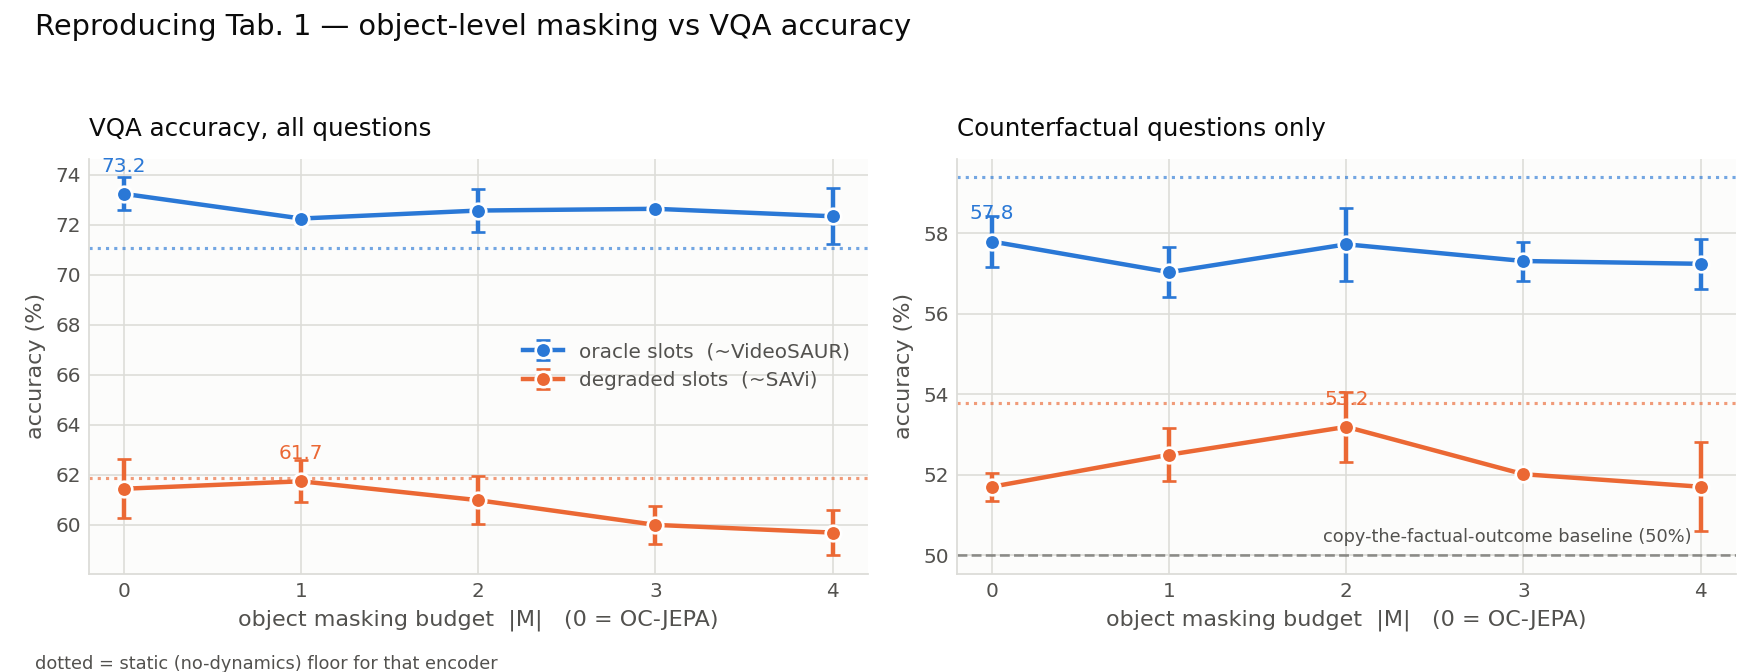

*Figure 1 — VQA accuracy vs masking budget. Dotted lines are the no-dynamics floor for each encoder; the dashed line in the right panel is the copy-the-factual-outcome baseline, pinned at 50% by construction.*


### 4.2 Influence neighborhoods — C4 reproduces clearly

This is the measurement the paper could not make. Scoring the predictor's
cross-slot attention against the **true collision graph** (AUROC):

| \|M\| | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| **attention**, oracle | 0.642 | 0.742 | 0.750 | 0.760 | 0.750 |
| **attention**, degraded | 0.624 | 0.720 | 0.693 | 0.688 | 0.704 |
| ablation, oracle | 0.494 | 0.540 | 0.509 | 0.515 | 0.536 |
| ablation, degraded | 0.497 | 0.497 | 0.498 | 0.537 | 0.538 |

The attention effect is **+0.11 AUROC** (oracle) and **+0.08** (degraded), in
*both* encoder arms, and in the oracle arm the separation is clean: the worst
masked run (0.728) beats the best unmasked run (0.694), across 8 runs versus 2.

### 4.3 …but attention alignment is not functional dependence

The ablation rows are the interesting ones. That probe removes object $j$ from
the predictor's context and measures how much worse masked object $i$'s
prediction becomes — a direct test of whether the model *uses* the true
interaction partners, which is what Definition 1 asserts and Theorem 1 needs.

It sits at **0.49 → 0.54** in both arms, barely above chance, with seed error
bars straddling 0.5. **The model's attention increasingly points at the right
objects while its computation stays only weakly dependent on them.**

This contradicts no theorem in the paper — Thm. 1 describes the loss-*optimal*
predictor, and these are not loss-optimal. What it undercuts is the *measurement
strategy*: the paper's evidence for Cor. 1 is attention maps (App. J, following
SPARTAN). Two probes on the same models disagree, and the attention one is the
optimistic one.


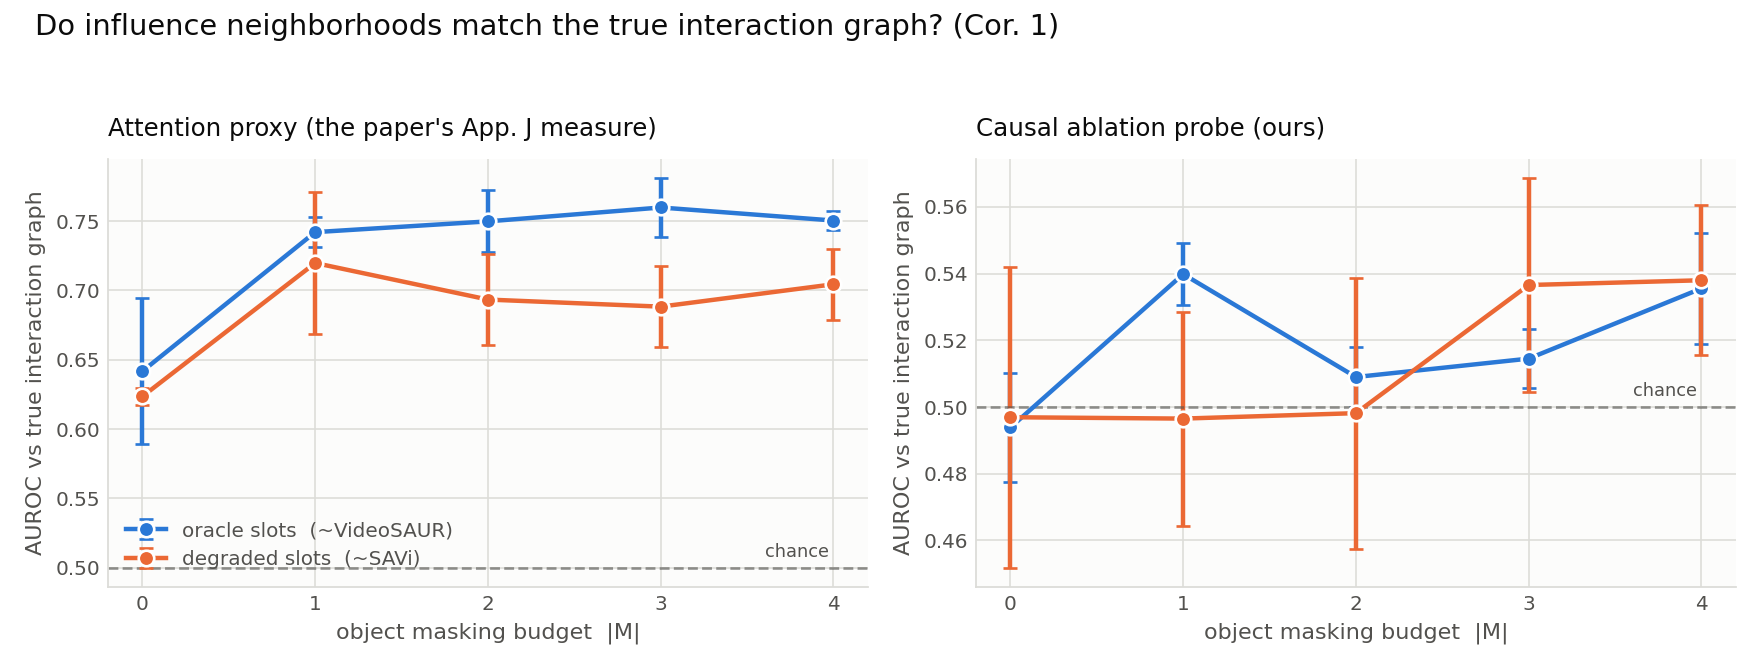

*Figure 2 — Attention alignment with the true interaction graph rises sharply with masking (left) while a causal ablation probe on the same models stays at chance (right).*


### 4.4 Probe-free measurements agree: no gain, a small cost

These touch the world model directly — no learned probe, so no bracket problem.
Oracle encoder, mean of 2 seeds:

| \|M\| | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| counterfactual gain | 0.234 | 0.225 | 0.225 | 0.226 | 0.218 |
| collision F1 | 0.370 | 0.371 | 0.332 | 0.343 | 0.329 |
| forward position error | 0.0371 | 0.0373 | 0.0372 | 0.0372 | 0.0382 |

Counterfactual gain is $1 - d_{\text{model}}/d_{\text{ignore}}$ under
$\mathrm{do}(\text{remove } k)$, so ~0.23 means every model *does* respond to the
intervention — its prediction lands ~23% closer to the true counterfactual than
simply predicting what factually happened. Masking does not improve that, and
collision F1 — the metric that isolates the interaction-dependent part of the
dynamics — drifts **down** at $|\mathcal{M}| \geq 2$.

The degraded arm's position-space metrics are omitted as uninformative, and we
can say exactly why: the read-out residual there is 0.180 while its measured
forward error is 0.193, so the read-out error *is* essentially the whole
measurement.


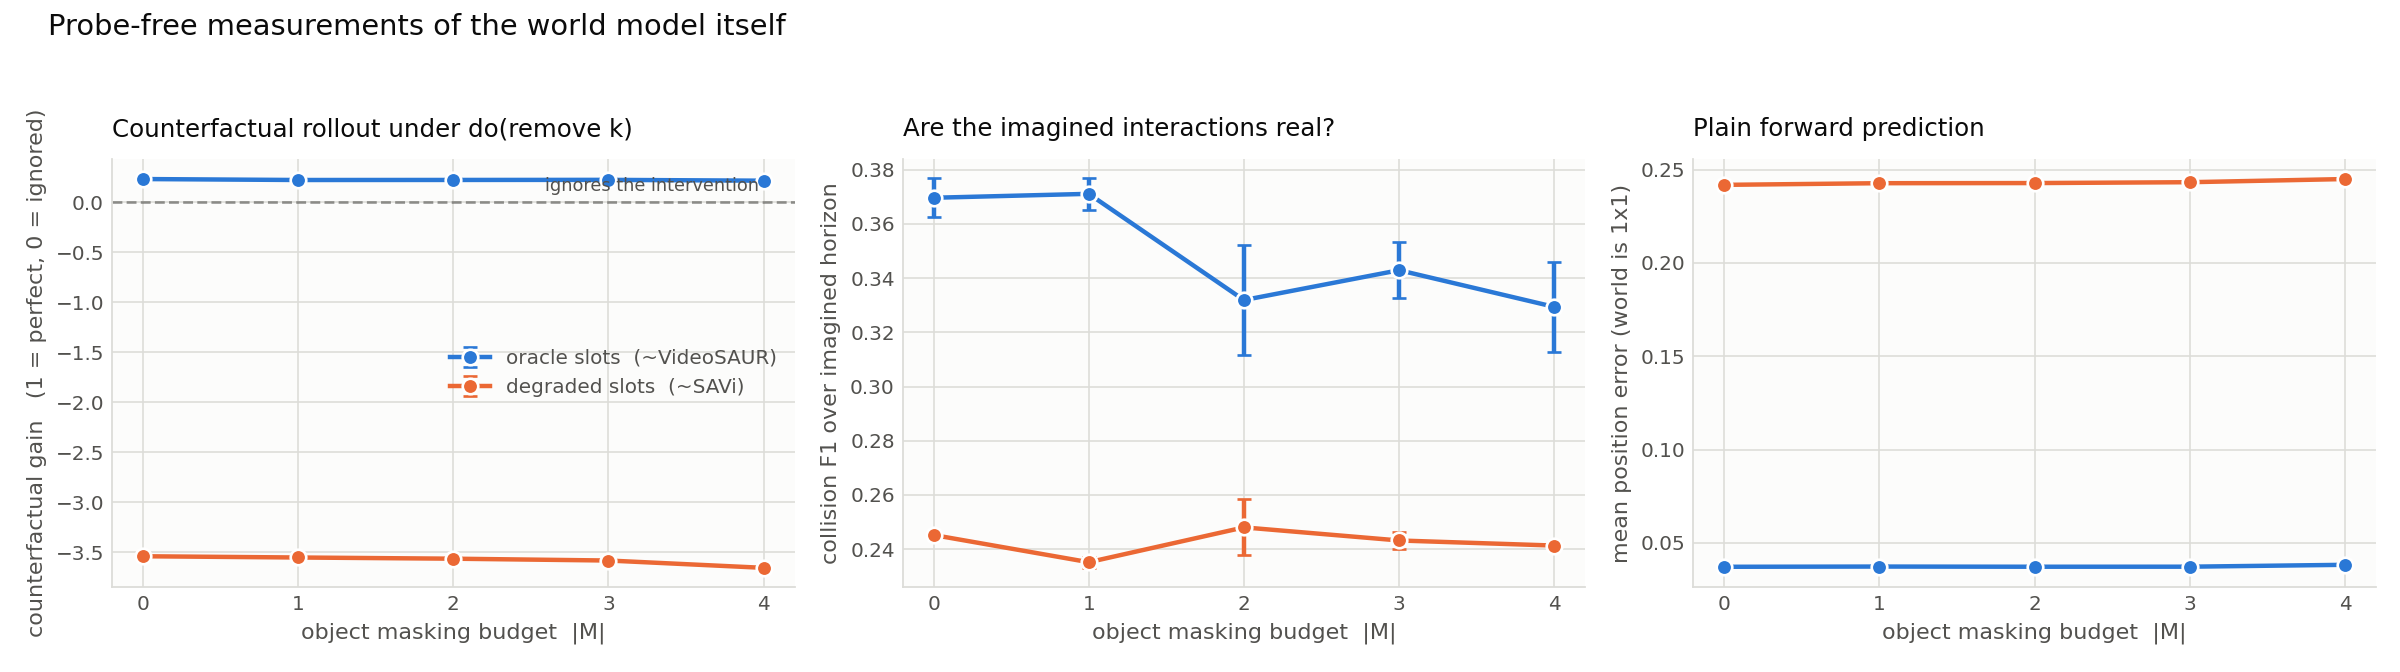

*Figure 3 — Probe-free measurements of the world model itself.*


### 4.5 Planning efficiency — C5 reproduces

The token arithmetic matches the paper exactly. The "6" is 4 object slots plus
one action and one proprioception token — auxiliaries are separate entities in
C-JEPA, not concatenated into the visual features.

```
C-JEPA    6 tokens × 128 =    768 features
DINO-WM   196      × 384 =  75264 features
ratio                        1.02%      paper: 1.02%
```

Under the paper's own CEM workload (App. G: 300 candidates, 30 iterations,
horizon 5, 10 replans/episode, 50 episodes), with **both arms using the same
predictor architecture**, the only difference is sequence length — 784 vs 24
tokens:

| | forward pass (batch 300) | 50 episodes |
|---|---|---|
| DINO-WM (patch) | 2241.3 ms | 168,095 s |
| C-JEPA (object) | 58.7 ms | 4,399 s |
| **speedup** | | **38.2×** |

The paper reports 8.56× on an L40s. Ours is larger because a T4 saturates much
earlier on the 784-token workload, inflating the patch arm. The claim under test
is ">8× faster planning" and it holds with room to spare; the exact multiplier is
hardware-dependent and should not be compared across GPUs.

This reproduces only the *efficiency* half of Table 3. The success-rate half
needs the Push-T environment and was not attempted.


## 5. Why C1/C2 probably didn't reproduce here

The honest answer is that this world is too easy for the mechanism to matter, and
something more specific can be said than that.

C-JEPA's extra term is $\mathcal{L}_{\text{history}}$: recover a masked object's
past from the other objects. The paper's argument is that this prevents "shortcut
solutions such as trivial temporal interpolation" — and that shortcut is real
*for history completion*. But $\mathcal{L}_{\text{future}}$ already applies
interaction pressure of its own: you cannot roll a multi-object scene forward ten
steps without predicting collisions. So the marginal value of the history term
depends on **how much interaction pressure the future term already applies**.

Here that pressure is nearly maximal. The encoder is lossless, the physics
exactly deterministic, the horizon short — OC-JEPA already reaches 0.036 mean
position error before any masking. There is little interaction structure left for
the history term to add, and it is not free: it spends capacity on an auxiliary
task, which is the most plausible reading of the small collision-F1 decline.

The paper's regime differs in exactly the ways that would widen the gap: a
learned, *lossy* encoder, a much longer rollout (128→160 frames vs 10 steps), and
real scene complexity. Notably the paper's own Table 1 supports this reading —
the weaker encoder is where masking behaves most dramatically, and most
erratically.

So: **object-level masking is not a free win; its value depends on the forward
objective being insufficient on its own.** The regime where the paper says it
matters is the one that could not be tested here.

The one thing masking demonstrably *did* do, even here, is reshape attention
toward genuine interaction partners. The mechanism operates. It just did not
convert into accuracy at this scale.

## 6. What was not tested

* Table 2 — SlotFormer / OCVP-Seq with and without reconstruction loss
* Table 3 success rates — needs the Push-T environment
* PHYRE qualitative study (App. J)
* Auxiliary-variable ablation (Fig. 3) — the predictor supports auxiliary entity
  tokens but this world has no actions
* Paper-width predictor (1024); everything here is width 256
* App. K token/tube masking comparison, and the identity-anchor ablation

## 7. Things worth remembering

1. **Bracket every learned-probe metric before the sweep.** Ceiling = probe on
   ground truth, floor = probe on no information. Ship it as a gate.
2. **"Untestable" and "refuted" are different claims.** Never let one read as the
   other.
3. **Check your labels for a degenerate shortcut policy** and report its score.
4. **Where a paper uses a proxy for a mechanism, add a causal version.** When they
   disagree, that is the finding.
5. **Read the appendices.** The main text never carries the hyperparameters.
6. `torch.linalg.lstsq` on CUDA assumes full rank and fails silently otherwise.
